# Tutorial: Protein–Ligand MD in 3 commands

This notebook sets up and runs a complete **protein–ligand molecular dynamics** simulation
using the **workflows** shipped in
[`biobb_md_workflows`](https://github.com/NBDsoftware/biobb_md_workflows).

The system is the **T4 lysozyme L99A/M102Q** mutant (PDB [`3HTB`](https://www.rcsb.org/structure/3HTB))
in complex with **2-propylphenol** (ligand [`JZ4`](https://www.rcsb.org/ligand/JZ4)) — the same
classic example as the [official GROMACS complex tutorial](http://www.mdtutorials.com/gmx/complex/index.html).

**The whole pipeline:**

| Step | Command | What it does |
|------|---------|--------------|
| 1 | `protein_preparation` | Clean, fix and protonate the protein |
| 2 | `ligand_parameterization` | Build GROMACS topology + coordinates for JZ4 |
| 3 | `md_gromacs` | Setup → energy minimization → NVT/NPT equilibration → production MD → analysis |

We then **visualize the trajectory**
and **plot the analyses** the MD workflow produces automatically.

Every command supports `--help`, and full docs live [here](https://nbdsoftware.github.io/biobb_md_workflows/).

## 1. Set up the environment

**Running on Google Colab?** The cell below installs everything: it downloads Miniforge and builds
the `biobb_md` conda environment — GROMACS, AmberTools, acpype, the BioBB packages, this repo's
workflows, and the visualization libraries (nglview, plotly, MDAnalysis).

This might take a while, the conda solve is the slow part. Run it once and wait.

If you are running this **locally** instead, skip this cell: create the environment from
`notebooks/local_environment.yml` and launch the notebook from it.

In [10]:
import sys, os

if 'google.colab' in sys.modules:
    # Install Miniforge + mamba
    !wget -q https://github.com/conda-forge/miniforge/releases/download/26.1.0-0/Miniforge3-26.1.0-0-Linux-x86_64.sh
    !bash Miniforge3-26.1.0-0-Linux-x86_64.sh -b -p /usr/local/miniforge

    # Clone the repo
    !git clone https://github.com/NBDsoftware/biobb_md_workflows.git

    # Build the biobb_md colab environment (yaml path is relative to the repo root)
    os.chdir('biobb_md_workflows')
    !/usr/local/miniforge/condabin/mamba env create -f notebooks/colab_environment.yml

    # Run from notebooks/ so the ../data/* input paths match the local layout
    os.chdir('notebooks')

    # Append (not prepend) the environment's site packages
    sys.path.append('/usr/local/miniforge/envs/biobb_md_tutorial/lib/python3.12/site-packages')
    # Put the env's binaries first so the workflow CLIs (and gmx, antechamber, ...) resolve.
    os.environ['PATH'] = '/usr/local/miniforge/envs/biobb_md_tutorial/bin:' + os.environ['PATH']

    from google.colab import output
    output.enable_custom_widget_manager()

print('Working directory:', os.getcwd())
import shutil
print('protein_preparation on PATH:', bool(shutil.which('protein_preparation')))

Working directory: /home/pnavarro/repos/NostrumBD/biobb_md_workflows/notebooks
protein_preparation on PATH: True


## 2. Inputs

We use the PDB complex bundled in the repo at `data/3HTB.pdb` (it already contains both the
protein and the JZ4 ligand). JZ4 (2-propylphenol) is **neutral**, so its formal charge is `0`.

In [11]:
pdb_code    = "3HTB"
ligand_code = "JZ4"
ligand_charge = 0
input_pdb   = "../data/3HTB.pdb"

assert os.path.exists(input_pdb), f"{input_pdb} not found - is the working dir the repo root?"
print("Input structure:", input_pdb)

Input structure: ../data/3HTB.pdb


Let's have a first look at the raw crystal structure (protein + ligand + crystallographic waters):

In [12]:
import nglview
view = nglview.show_structure_file(input_pdb)
view

NGLWidget()

## 3. Step 1 — Protein preparation

The `protein_preparation` workflow takes the raw PDB and returns a clean, MD-ready protein:
it extracts the protein, fixes structural defects (alternate locations, missing side chains,
disulfide bonds, amides, chirality), and assigns **protonation states** of titratable residues
at the requested pH (via propka + reduce).

We ask for **GROMACS-style** residue naming (`--output_format gromacs`) because the MD step uses
GROMACS. No Modeller license key is needed here: 3HTB has no gaps.

The heteroatoms (the ligand) are stripped from the protein output — that's expected. The ligand
is parameterized separately in the next step, directly from the original PDB.

In [13]:
!protein_preparation \
    --input_pdb ../data/3HTB.pdb \
    --output prot_prep \
    --ph 7 \
    --output_format gromacs \
    --restart

12:56:27 step1_extractAtoms: extract chain of interest
12:56:27     Module: biobb_structure_utils.utils.extract_molecule Version: 5.2.1
12:56:30     Command 'check_structure -i /home/pnavarro/repos/NostrumBD/biobb_md_workflows/data/3HTB.p...' finalized with exit code 0
12:56:30     
12:56:30 step2_fixaltlocs: Fix alternative locations
12:56:30 Found residues with alternative locations: ['A1:A', 'A21:A', 'A24:A', 'A68:A', 'A72:A', 'A80:A', 'A96:A', 'A102:A', 'A147:A', 'A154:A']
12:56:30     Module: biobb_model.model.fix_altlocs Version: 5.2.1
12:56:30     Command 'check_structure -i /home/pnavarro/repos/NostrumBD/biobb_md_workflows/notebooks/s...' finalized with exit code 0
12:56:30     
12:56:30     Module: biobb_model.model.mutate Version: 5.2.1
12:56:30     Command 'check_structure -i /home/pnavarro/repos/NostrumBD/biobb_md_workflows/notebooks/s...' finalized with exit code 0
12:56:30     
12:56:30 step4_canonical_fasta: Using PDB code (3HTB) extracted from the input PDB file.
12:56:

The final prepared protein is written to the top of the output folder, named after the input
(`prot_prep/3HTB.pdb`). Intermediate per-step folders (`step1_extractAtoms/`, `step13_propka/`, …)
and the auto-generated `config.yml` are kept alongside for inspection.

In [14]:
prepared_protein = "prot_prep/3HTB.pdb"
assert os.path.exists(prepared_protein)
print("Prepared protein:", prepared_protein)
nglview.show_structure_file(prepared_protein)

Prepared protein: prot_prep/3HTB.pdb


NGLWidget()

## 4. Step 2 — Ligand parameterization

`ligand_parameterization` generates a **GROMACS topology + coordinates** for the ligand. With no
custom AMBER parameters supplied, it takes the GAFF route: protonate → energy-minimize →
`acpype` (antechamber/GAFF).

We point it at the **original** `data/3HTB.pdb` (which still contains the JZ4 heteroatoms),
restrict it to `JZ4`, give its charge, and request GROMACS format.

In [15]:
!ligand_parameterization \
    --input_pdb ../data/3HTB.pdb \
    --output lig_param \
    --ligands JZ4 \
    --charges JZ4:0 \
    --format gromacs \
    --protonation_tool obabel \
    --restart

12:56:35 Searching selected ligands in the input PDB file: JZ4
12:56:35 Found 1 ligands in the input PDB file: JZ4
12:56:35 Parameterizing JZ4 using GAFF through acpype
12:56:35 step2B_obabel_reduce: Add hydrogens to the ligand
12:56:35 step3B_babel_minimize: Energetically minimize the ligand
12:56:35 step4B_acpype_params_gmx: Generating GROMACS ligand parameters
12:56:37 
12:56:37 
12:56:37 Execution successful: 
12:56:37   Workflow_path: /home/pnavarro/repos/NostrumBD/biobb_md_workflows/notebooks/lig_param
12:56:37   Config File: /home/pnavarro/repos/NostrumBD/biobb_md_workflows/notebooks/lig_param/config.yml
12:56:37 
12:56:37 Elapsed time: 0.0 minutes
12:56:37 


The deliverable is the `topologies/` folder, with one `.itp` + `.gro` pair per ligand:

In [16]:
ligands_folder = "lig_param/topologies"
print(os.listdir(ligands_folder))
assert os.path.exists(os.path.join(ligands_folder, "JZ4.itp"))
assert os.path.exists(os.path.join(ligands_folder, "JZ4.gro"))

['JZ4.itp', 'JZ4.gro']


## 5. Step 3 — MD simulation

`md_gromacs` runs the full GROMACS pipeline in four sections:

1. **`1_setup`** — build topology (`pdb2gmx`), insert the ligand + restraints, solvate, add ions
2. **`2_equil`** — energy minimization, NVT and NPT equilibration
3. **`3_prod`** — production MD
4. **`4_analysis`** — RMSD / radius of gyration / RMSF, then trajectory post-processing
   (strip solvent, center, image, fit)

The outputs of the two previous steps chain straight in: the prepared protein as `--input_pdb`
and the ligand topology folder as `--ligands_folder`.

We use **very short** equilibration/production times (`0.1 ns` each) so the demo finishes quickly.
GROMACS from conda is **CPU-only**, so even this short run may take several minutes. For real
science you would raise `--prod_time` and run with an externally compiled GROMACS version with GPU support.

In [ ]:
!md_gromacs \
    --input_pdb prot_prep/3HTB.pdb \
    --ligands_folder lig_param/topologies \
    --output md \
    --gmx_bin gmx \
    --equil_time 0.05 \
    --prod_time 0.05 \
    --restart

14:17:26 Using PDB as input:
14:17:26 Input PDB file: prot_prep/3HTB.pdb
14:17:26 step1_pdb2gmx: Reading protonation states for titratable residues (0: deprotonated, 1: protonated)
14:17:26 step1_pdb2gmx: LYS protonation state: ['1 1 1 1 1 1 1 1 1 1 1 1 1']
14:17:26 step1_pdb2gmx: ARG protonation state: ['1 1 1 1 1 1 1 1 1 1 1 1 1']
14:17:26 step1_pdb2gmx: ASP protonation state: ['0 0 0 0 0 0 0 0 0 0 0 0']
14:17:26 step1_pdb2gmx: GLU protonation state: ['0 0 0 0 0 0 0 0']
14:17:26 step1_pdb2gmx: Generate the topology
14:17:26 A > Create index group for the chain
14:17:26 A > Create index group for the chain's CA atoms
14:17:26 step4_append_posres: Append restraints to the topology
14:17:26 step5_structure_pdb: Convert GRO to PDB
14:17:26 JZ4 > Convert ligand GRO to PDB
14:17:26 JZ4 > Create complex PDB file
14:17:26 JZ4 > Create index file for the ligand's heavy atoms
14:17:26 JZ4 > Generate restraints for ligand
14:17:26 JZ4 > Append ligand to the topology
14:17:26 step6_editconf: Cre

## 6. Visualize the trajectory

The MD workflow already post-processed the raw trajectory for us: it removed the solvent, and
centered/imaged/fitted the solute. We load the **dry reference structure** together with the
**fitted trajectory** and view it with NGLView (via MDAnalysis, which works in Colab).

In [23]:
import MDAnalysis as mda
import nglview

topology   = "md/4_analysis/step6_dry_str/dry_structure.pdb"
trajectory = "md/4_analysis/step10_fit_traj/fitted_traj.xtc"

u = mda.Universe(topology, trajectory)
print(f"{len(u.trajectory)} frames, {len(u.atoms)} atoms")

view = nglview.show_mdanalysis(u)
view.add_representation("licorice", selection="resname JZ4")  # highlight the ligand
view

2084 frames, 2637 atoms


/home/pnavarro/miniforge3/envs/biobb_md_tutorial/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:372: UserWarning: Unknown element  found for some atoms. These have been given an empty element record. If needed they can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn(wmsg)


NGLWidget(max_frame=2083)

## 7. Analysis plots

`md_gromacs` writes standard analysis curves as `.xvg`/`.xmgr` files under `4_analysis/`. Here we
read them and plot with Plotly:

* **RMSD** of the protein backbone vs. the equilibrated and experimental structures
* **Radius of gyration** (compactness) over time
* **RMSF** (per-residue flexibility)
* **Ligand RMSD** (JZ4 pose stability, heavy atoms only, no re-fit)

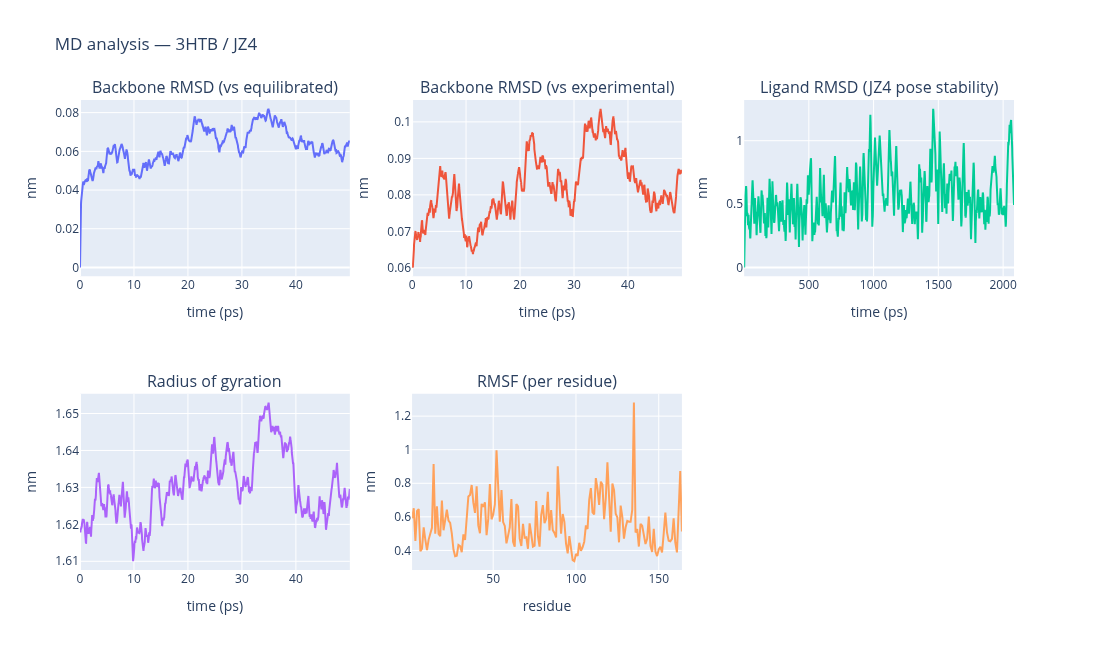

In [24]:
import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots

def read_xvg(path):
    """Load an .xvg/.xmgr file, skipping GROMACS comment/legend lines."""
    data = np.loadtxt(path, comments=['#', '@'])
    return data[:, 0], data[:, 1]

A = "md/4_analysis"
rmsd_eq_x,  rmsd_eq_y  = read_xvg(f"{A}/step13_rmsd_equilibrated/md_rmsdfirst.xvg")
rmsd_exp_x, rmsd_exp_y = read_xvg(f"{A}/step14_rmsd_experimental/md_rmsdexp.xvg")
rgyr_x,     rgyr_y     = read_xvg(f"{A}/step15_rgyr/md_rgyr.xvg")
rmsf_x,     rmsf_y     = read_xvg(f"{A}/step16_rmsf/md_rmsf.xmgr")
lig_rmsd_x, lig_rmsd_y = read_xvg(f"{A}/step17_rmsd_ligand/md_rmsd_ligand_JZ4.xmgr")

fig = make_subplots(rows=2, cols=3, subplot_titles=(
    "Backbone RMSD (vs equilibrated)", "Backbone RMSD (vs experimental)", "Ligand RMSD (JZ4 pose stability)",
    "Radius of gyration", "RMSF (per residue)", ""))
fig.add_trace(go.Scatter(x=rmsd_eq_x,  y=rmsd_eq_y),  row=1, col=1)
fig.add_trace(go.Scatter(x=rmsd_exp_x, y=rmsd_exp_y), row=1, col=2)
fig.add_trace(go.Scatter(x=lig_rmsd_x, y=lig_rmsd_y), row=1, col=3)
fig.add_trace(go.Scatter(x=rgyr_x,     y=rgyr_y),     row=2, col=1)
fig.add_trace(go.Scatter(x=rmsf_x,     y=rmsf_y),     row=2, col=2)
fig.update_xaxes(title_text="time (ps)", row=1, col=1)
fig.update_xaxes(title_text="time (ps)", row=1, col=2)
fig.update_xaxes(title_text="time (ps)", row=1, col=3)
fig.update_xaxes(title_text="time (ps)", row=2, col=1)
fig.update_xaxes(title_text="residue",   row=2, col=2)
fig.update_yaxes(title_text="nm", row=1, col=1); fig.update_yaxes(title_text="nm", row=1, col=2)
fig.update_yaxes(title_text="nm", row=1, col=3)
fig.update_yaxes(title_text="nm", row=2, col=1); fig.update_yaxes(title_text="nm", row=2, col=2)
fig.update_layout(height=650, showlegend=False, title_text="MD analysis — 3HTB / JZ4")
fig.show()

## 8. Wrap-up

In three workflow commands you went from a raw PDB complex to an analyzed MD trajectory:

```
protein_preparation  →  ligand_parameterization  →  md_gromacs
```

What replaced dozens of manual building-block calls is now three self-documenting CLIs. To go
further:

* Run any command with `--help` to see all options (force field, ion concentration, temperature,
  GPU offload with `--use_gpu`, multi-node MPI, PLUMED, …).
* `traj_postprocessing` — the fourth workflow — post-processes a trajectory produced elsewhere
  (strip solvent, center, image, fit), the same cleanup `md_gromacs` runs internally.
* Full documentation: <https://nbdsoftware.github.io/biobb_md_workflows/>.